# Vulnerabilidad Socioterritorial en Chile

Análisis del Índice de Geografía de la Vulnerabilidad Urbana y Social Territorial (IGVUST) y de datos del CENSO 2024

Renato De Luca (Universidad de Chile)  
September 16, 2026

In [ ]:
source("../processing/analisis_igvust.R")


Attaching package: 'dplyr'

The following objects are masked from 'package:stats':

    filter, lag

The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union

Loading required package: sf

Linking to GEOS 3.13.0, GDAL 3.8.5, PROJ 9.5.1; sf_use_s2() is TRUE

...

# A tibble: 16 × 6
   Region     codigo_region prom_c_ig_nac n_comunas_q1 n_comunas prop_comunas_q1
   <chr>      <chr>                 <dbl>        <int>     <int>           <dbl>
 1 La Arauca… 09                     1.38           23        32          0.719 
 2 Ñuble      16                     1.48           13        21          0.619 
 3 Arica y P… 15                     1.5             2         4          0.5   
 4 Biobío     08                     2.09           12        33          0.364 
 5 Aysén del… 11                     2.5             3        10          0.3   
 6 Tarapacá   01                     2.14            2         7          0.286 
 7 Los Lagos  10                     2.23            8        30          0.267 
 8 Coquimbo   04                     2.33            3        15          0.2   
 9 Maule      07                     2.33            6        30          0.2   
10 Libertado… 06                     2.58            6        33          0.182 
11 Los Rí


Attaching package: 'janitor'

The following objects are masked from 'package:stats':

    chisq.test, fisher.test


Attaching package: 'cowplot'

The following object is masked from 'package:lubridate':

    stamp

The following object is masked from 'package:patchwork':

    align_plots


Attaching package: 'scales'

The following object is masked from 'package:purrr':

    discard

The following object is masked from 'package:readr':

    col_factor

New names:ℹ Limpiando 346 nombres de región (17 son distintos)
→ Paso 1: confirmar regiones correctas
ℹ De las 17 regiones distintas, ninguna tiene nombres 100% correctos. Los siguientes pasos intentarán la limpieza
→ Paso 2: coincidencias por limpieza de texto
ℹ A partir de la limpieza de texto, se limpiaron 17 de 17 regiones: Arica y Parinacota, Tarapacá, Antofagasta, Atacama, Coquimbo, Valparaíso, Metropolitana de Santiago, Libertador General Bernardo O'Higgins, Maule, Ñuble, Biobío, La Araucanía, Los Ríos, Los Lagos, Aysén del Gener

ℹ In argument: `indice_envejecimiento = as.numeric(indice_envejecimiento)`.
Caused by warning:
! NAs introduced by coercion

ℹ In argument: `cod_com = as.numeric(cod_com)`.
Caused by warning:
! NAs introduced by coercion

# A tibble: 16 × 6
   Region       prom_c_ig_nac idh_prom icfsr_prom irape_prom envejecimiento_prom
   <chr>                <dbl>    <dbl>      <dbl>      <dbl>               <dbl>
 1 La Araucanía          1.38    0.489      0.374      0.351                91.0
 2 Ñuble                 1.48    0.528      0.385      0.350               115. 
 3 Arica y Par…          1.5     0.621      0.488      0.254               119. 
 4 Biobío                2.09    0.576      0.344      0.310                92.0
 5 Tarapacá              2.14    0.556      0.343      0.306                55.5
 6 Los Ríos              2.17    0.537      0.237      0.291                91.7
 7 Los Lagos             2.23    0.556      0.399      0.332                96.9
 8 Coquimbo              2.33    0.590      0.376      0.321               102. 
 9 Maule                 2.33    0.552      0.371      0.327                96.9
10 Aysén del G…          2.5     0.620      0.470      0.327                78.1
11 Libert

# Análisis IGVUST

## ¿Cómo se construye el IGVUST?

El Índice Global de Vulnerabilidad Socioterritorial (IGVUST) es un indicador sintético desarrollado por el Ministerio de Desarrollo Social y Familia de Chile, dentro del Sistema de Indicadores de Vulnerabilidad Socioterritorial (SIVUST). Su objetivo es caracterizar comparativamente los distintos territorios del país en términos de su vulnerabilidad socioterritorial, entendida como la exposición a riesgos que afectan la vida de las personas debido a la ausencia o insuficiencia de activos protectores y a la debilidad en la estructura de oportunidades \[@minsoc_sivust_2025\]

- **Escala territorial.** La unidad de análisis mínima del SIVUST es la **Unidad Vecinal** (existen 6.887 en el país), y a partir de ella los indicadores se agregan también a nivel comunal y regional. Los datos utilizados en este análisis corresponden a la agregación comunal del índice.

- **Fuentes de datos.** El índice integra información de múltiples registros administrativos del Estado (incluyendo el Registro Civil e Identificación, los Ministerios de Educación y de Salud, la Superintendencia de Seguridad Social y el Instituto Nacional de Estadísticas, entre otros) con el Registro Social de Hogares (RSH) como base poblacional principal.

- **Dimensiones e indicadores.** El IGVUST se construye a partir de **18 indicadores** agrupados en **siete dimensiones**: Ingresos, Trabajo y Pensiones, Salud y Dependencia, Educación, Vivienda, Accesibilidad y Seguridad. Estas corresponden a la fase actual del sistema; el marco conceptual original contempla además las dimensiones de Medioambiente y Desarrollo y Gestión Territorial, no incorporadas aún por falta de información oficial con cobertura nacional. Cada indicador fue seleccionado según criterios técnicos y estadísticos, priorizando aquellos con asociación robusta e inequívoca con la vulnerabilidad, baja correlación entre sí (para evitar redundancia) y buena capacidad discriminativa entre territorios.

- **Tratamiento estadístico.** Antes de agregarse, los indicadores pasan por un proceso de imputación de datos faltantes, truncamiento de valores atípicos, y reescalamiento min-max a una escala común entre 0 y 1. Adicionalmente, los indicadores cuya relación original es “positiva” con el bienestar (Ingreso CSE, Empleo de Larga Duración, Actividad Laboral Registrada) se invierten tras el reescalamiento, de modo que en todos los indicadores del índice, **valores más altos representan siempre mayor vulnerabilidad**.

- **Ponderación y agregación.** Los 18 indicadores se combinan en un único índice mediante ponderadores obtenidos a través de un **Análisis Factorial Exploratorio (AFE)**, método escogido tras comparar alternativas (componentes principales, pesos uniformes, criterio experto) por sus propiedades estadísticas, interpretabilidad y estabilidad. El Ministerio reporta que este esquema de ponderación resultó ser el más robusto ante perturbaciones marginales y cambios en la selección de indicadores.

- **Lectura del resultado.** El valor final del índice se traduce en cuartiles y en un ranking nacional. Los valores menores (cuartil 1 o ranking 1) corresponden a mayor vulnerabilidad, mientras que los valores mayores representan menor vulnerabilidad relativa. Esta es la lógica utilizada a lo largo de este análisis: las comunas en cuartil 1 (`c_ig_nac == 1`) son las de mayor vulnerabilidad socioterritorial relativa dentro del país.

- **Actualización.** El IGVUST se recalcula mensualmente, reflejando tanto los cambios que las personas realizan en el RSH (composición familiar, domicilio, condiciones laborales o de salud) como las actualizaciones de las bases administrativas utilizadas en su construcción.

## Mapa Nacional

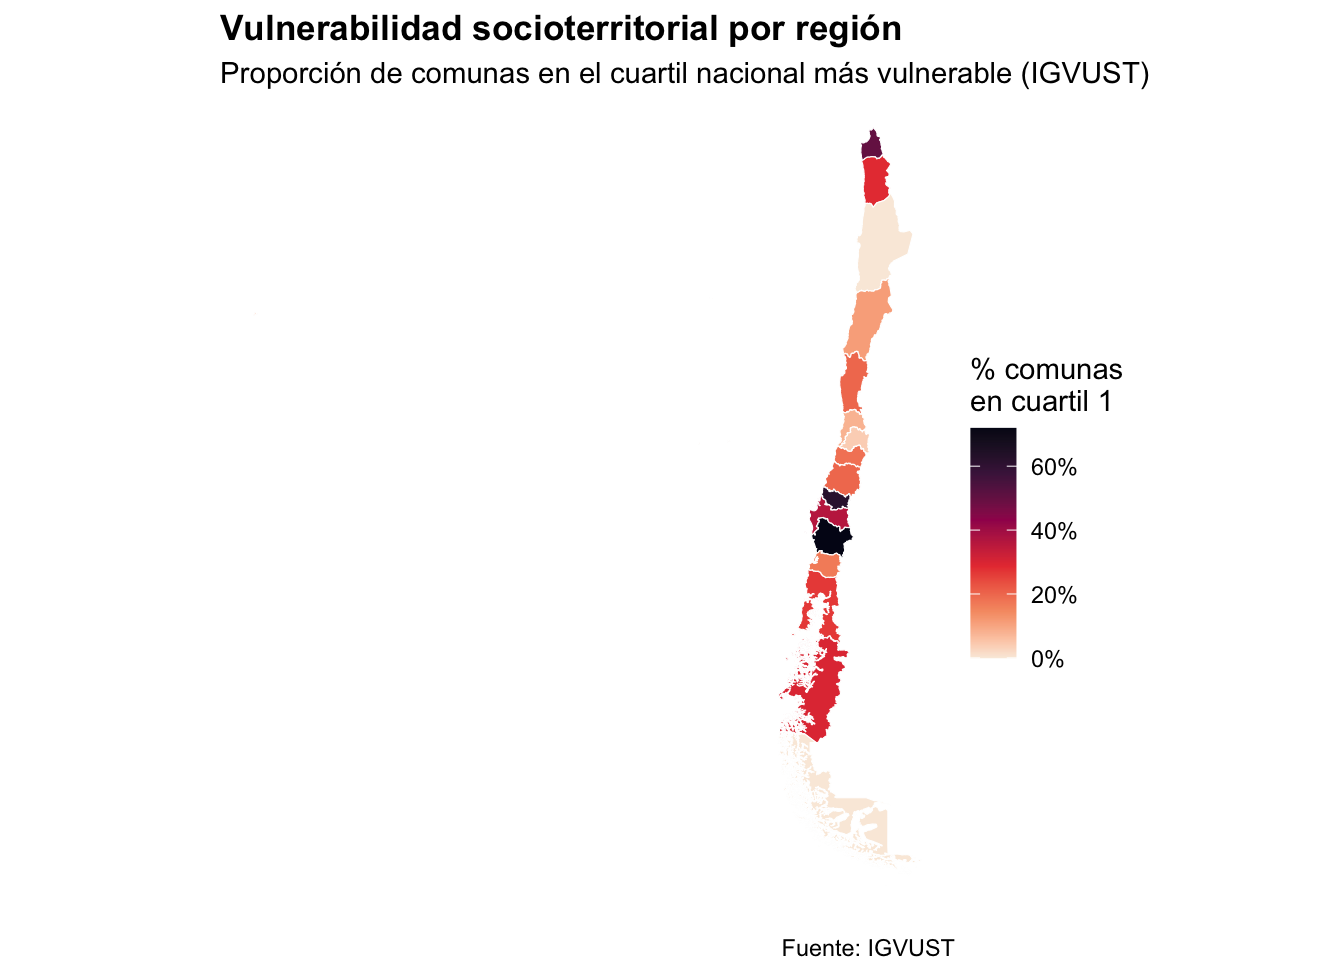

In [ ]:
grafico_mapa_nacional

> **Hallazgo Principal**
>
> Las comunas en el cuartil 1 (más vulnerable) están concentradas en regiones específicas del país, mostrando patrones claros de desigualdad socioterritorial.

## Las 3 Regiones Más Vulnerables

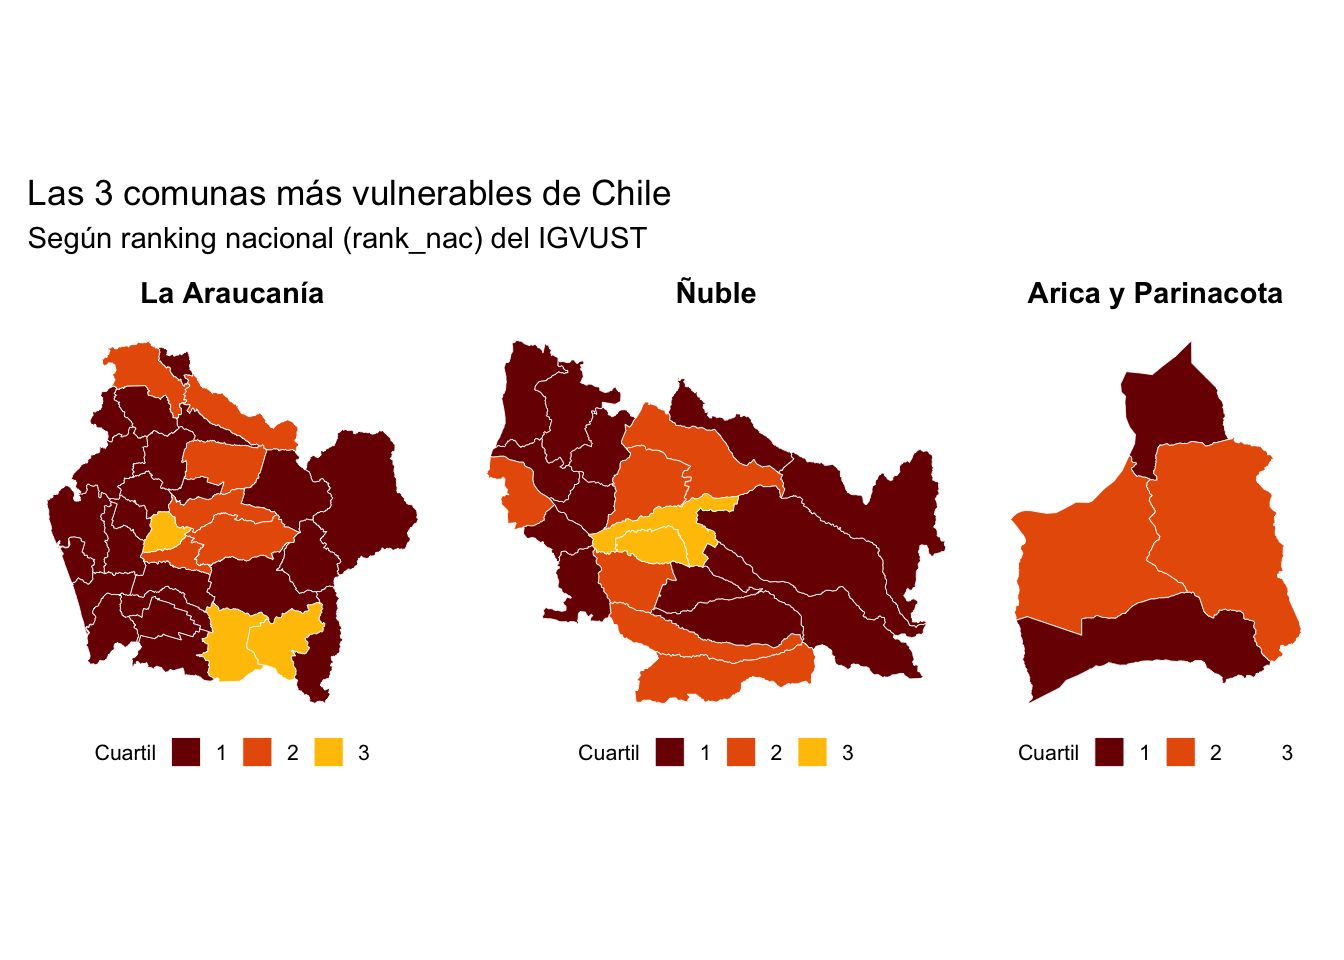

In [ ]:
patchwork::wrap_plots(mapas_top3, ncol = 3) +
  patchwork::plot_annotation(title = "Las 3 comunas más vulnerables de Chile",
                   subtitle = "Según ranking nacional (rank_nac) del IGVUST")

> **Contexto Regional**
>
> Estas comunas son las más vulnerables del país según el IGVUST, y se encuentran en regiones con concentraciones significativas de vulnerabilidad.

## Descriptivos por Región

In [ ]:
regiones_vulnerabilidad %>%
  mutate(across(where(is.numeric), ~round(., 3))) %>%
  arrange(desc(prop_comunas_q1)) %>%
  select(-codigo_region) %>%
  knitr::kable(
    col.names = c("Región", "Promedio IGVUST", "N° Comunas Q1", "Total Comunas", "% Comunas Q1"),
    caption = "Indicadores de vulnerabilidad por región",
    format = "html"
  )

  Región                                        Promedio IGVUST   N° Comunas Q1   Total Comunas   \% Comunas Q1
  ------------------------------------------- ----------------- --------------- --------------- ---------------
  La Araucanía                                            1.375              23              32           0.719
  Ñuble                                                   1.476              13              21           0.619
  Arica y Parinacota                                      1.500               2               4           0.500
  Biobío                                                  2.091              12              33           0.364
  Aysén del General Carlos Ibáñez del Campo               2.500               3              10           0.300
  Tarapacá                                                2.143               2               7           0.286
  Los Lagos                                               2.233               8              30           0.267
  Coquimbo                                                2.333               3              15           0.200
  Maule                                                   2.333               6              30           0.200
  Libertador General Bernardo O\'Higgins                  2.576               6              33           0.182
  Los Ríos                                                2.167               2              12           0.167
  Atacama                                                 2.889               1               9           0.111
  Valparaíso                                              2.974               3              38           0.079
  Metropolitana de Santiago                               3.462               2              52           0.038
  Antofagasta                                             3.556               0               9           0.000
  Magallanes y de la Antártica Chilena                    3.818               0              11           0.000

  : Indicadores de vulnerabilidad por región {quarto-postprocess="true"}


## Conclusiones

> **Observaciones Clave**
>
> - La distribución de vulnerabilidad no es uniforme a lo largo del territorio
> - Existen regiones con concentraciones significativas de comunas vulnerables
> - Se identifican oportunidades para intervenciones territoriales focalizadas

> **Limitaciones de los datos**
>
> La variable de cobertura comunal del Registro Social de Hogares (`p_cobertura_com`) supera el 100% en 101 de las 346 comunas del país (29%), principalmente en comunas rurales o de baja población, lo que sugiere un desajuste entre la población de referencia utilizada y el número de personas efectivamente registradas. Esto no afecta directamente el cálculo oficial del IGVUST, pero sí limita la confiabilidad de esta variable como indicador de representatividad para algunas comunas. Cabe destacar el caso de Constitución (Maule), clasificada en el cuartil más vulnerable, cuya cobertura del RSH es de solo 48,5%, por lo que su resultado debe interpretarse con cautela.

------------------------------------------------------------------------

# Análisis CENSO y Factores subyacentes

## Relación entre IGVUST y factores subyacentes (desarrollo, envejecimiento y riesgo de desastres)

Para complementar el análisis del IGVUST, se incorporó la base de **Factores Subyacentes del Riesgo de Desastres**, que agrega tres índices comunales adicionales: el Índice de Desarrollo Humano (IDH), el Índice Comunal de Factores Subyacentes del Riesgo de Desastres (ICFSR) y el Índice de Riesgo Ajustado por Envejecimiento (IRAPE), además del Índice de Envejecimiento poblacional.

In [ ]:
tabla_correlaciones <- tibble::tibble(
  Índice = c("IDH", "ICFSR", "IRAPE", "Índice de Envejecimiento"),
  Pearson = c(0.80, -0.28, -0.53, -0.37),
  Spearman = c(0.83, -0.29, -0.50, -0.41),
  Fuerza = c("Fuerte", "Débil", "Moderada", "Moderada"),
  Dirección = c("Positiva", "Negativa", "Negativa", "Negativa")
)

tabla_correlaciones %>%
  knitr::kable(
    caption = "Correlación entre el ranking nacional IGVUST y otros índices comunales",
    digits = 2,
    format = "html"
  )

  Índice                       Pearson   Spearman Fuerza     Dirección
  -------------------------- --------- ---------- ---------- -----------
  IDH                             0.80       0.83 Fuerte     Positiva
  ICFSR                          -0.28      -0.29 Débil      Negativa
  IRAPE                          -0.53      -0.50 Moderada   Negativa
  Índice de Envejecimiento       -0.37      -0.41 Moderada   Negativa


> **Cómo leer esta tabla**
>
> El ranking nacional IGVUST (`rank_nac`) asigna el valor 1 a la comuna más vulnerable del país. Por lo tanto, una correlación **positiva** indica que el índice comparado aumenta junto con la disminución de la vulnerabilidad (comunas menos vulnerables tienen valores más altos de ese índice), mientras que una correlación **negativa** indica lo contrario: el índice aumenta a medida que la vulnerabilidad IGVUST es mayor.

`geom_smooth()` using formula = 'y ~ x'

(`stat_smooth()`).

(`geom_point()`).

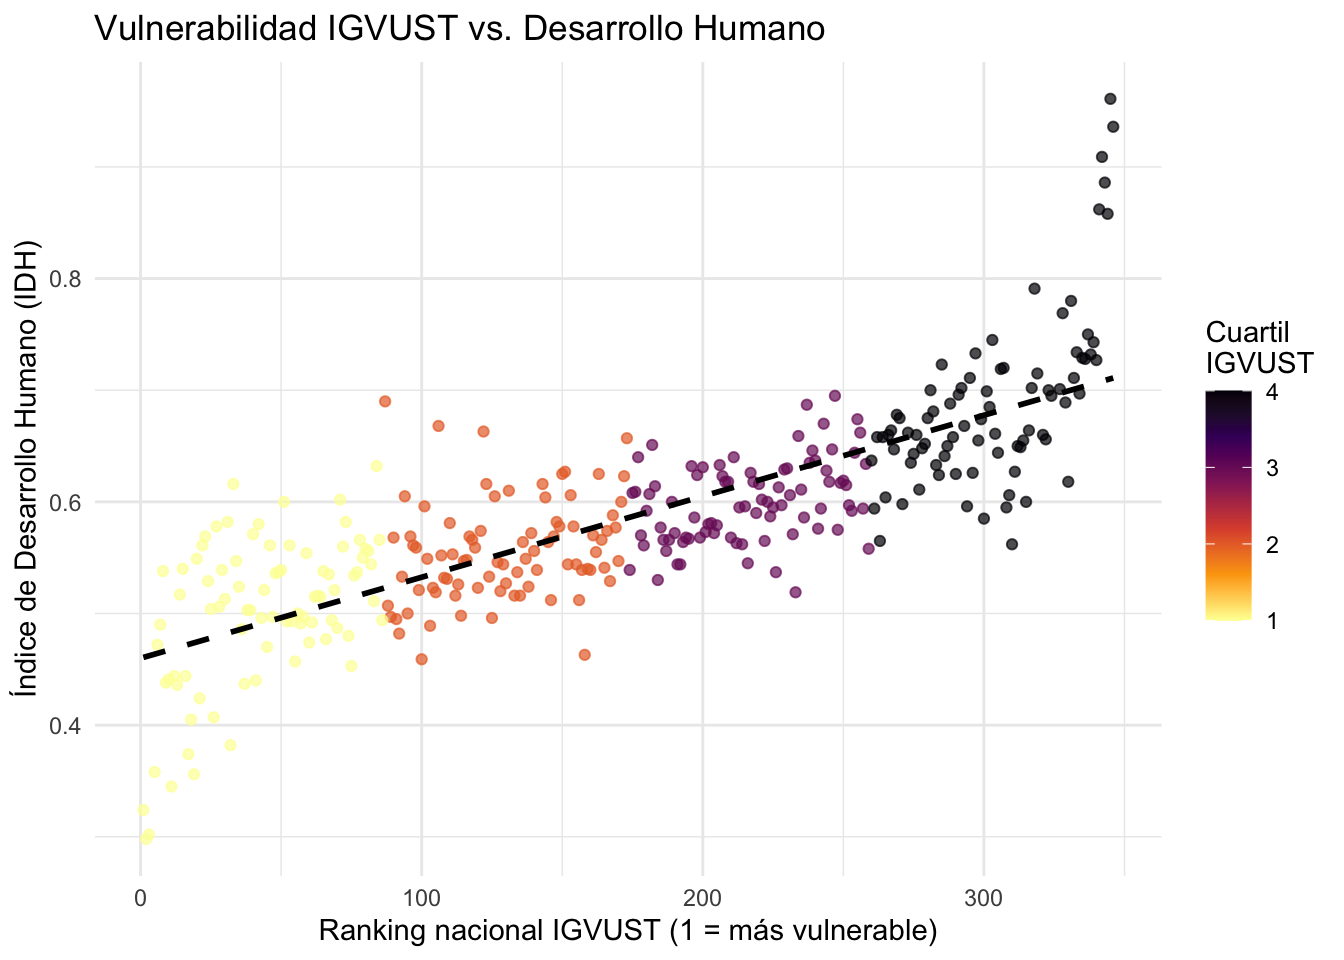

In [ ]:
grafico_idh

`geom_smooth()` using formula = 'y ~ x'

(`stat_smooth()`).

(`geom_point()`).

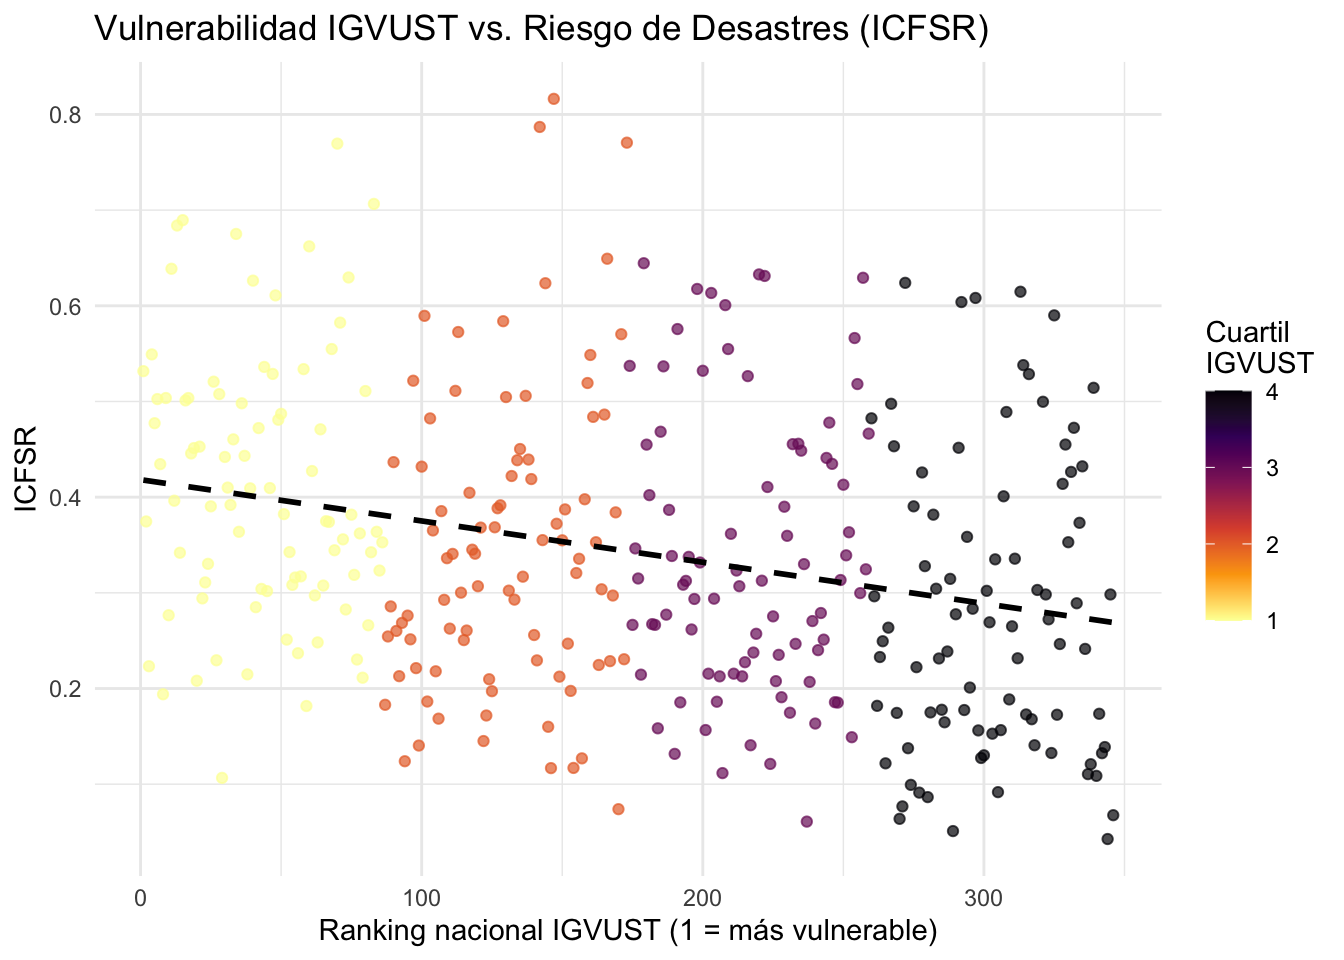

In [ ]:
grafico_icfsr

Los resultados muestran una **relación fuerte y consistente entre el IGVUST y el desarrollo humano** (r = 0.80, ρ = 0.83): las comunas menos vulnerables socioterritorialmente tienden a tener mayor desarrollo humano, lo que valida la coherencia interna entre ambos indicadores. La relación con el **envejecimiento poblacional es moderada** (ρ = -0.41), sugiriendo que las comunas más vulnerables tienden a tener una población más envejecida.

> **Precaución conceptual**
>
> A pesar de la correlación negativa entre envejecimiento y vulnerabilidad, no debemos olvidar lo que presentó Juan Pablo:
>
> No debe equipararse directamente el envejecimiento con la vulnerabilidad. Un modelo conceptual más adecuado plantea una cadena causal: **envejecimiento → capacidad funcional → dependencia → exposición → condiciones territoriales → vulnerabilidad ante desastres**. La correlación observada en este análisis es, por tanto, una asociación indirecta y no debe interpretarse como causalidad directa.

En contraste, la asociación entre el IGVUST y el **riesgo de desastres naturales (ICFSR)** es considerablemente más débil (r = -0.28, ρ = -0.29). Esto indica que la vulnerabilidad socioterritorial y el riesgo de desastres son **dimensiones relativamente independientes**: una comuna puede presentar alta vulnerabilidad social sin necesariamente estar expuesta a un riesgo elevado de desastres, y viceversa — patrón que se observa con claridad en el mapa bivariado presentado a continuación.

## Mapa bivariado: vulnerabilidad social y riesgo de desastres

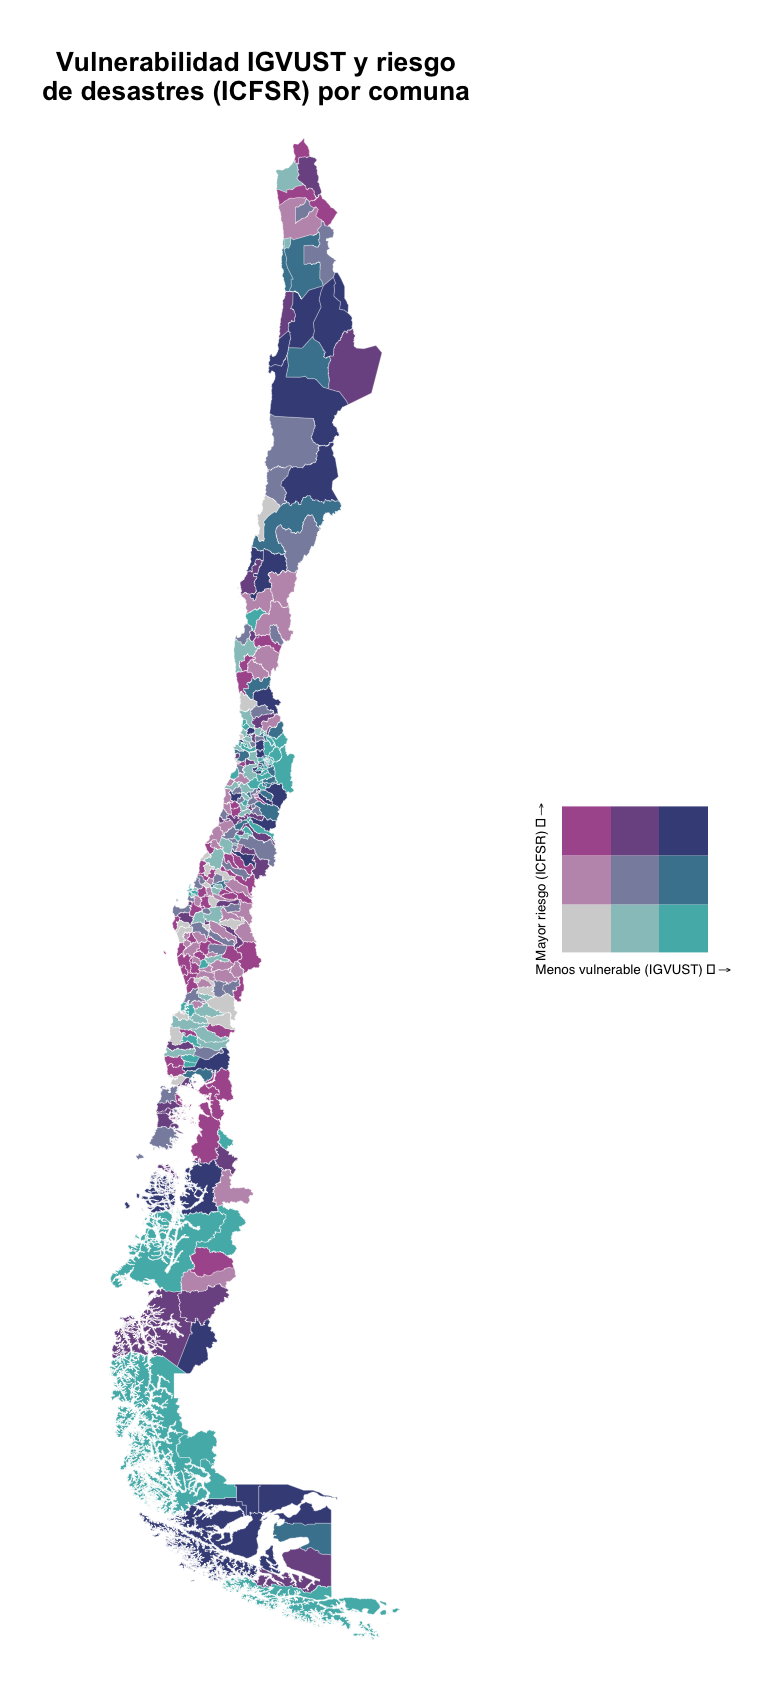

In [ ]:
library(patchwork)


# mapa 
mapa_bivariado <- ggplot() +
  geom_sf(data = mapa_biv, aes(fill = bi_class), color = "white", linewidth = 0.05, show.legend = FALSE) +
  bi_scale_fill(pal = "DkBlue2", dim = 3) +
  coord_sf(xlim = c(-76, -66), ylim = c(-56, -17), expand = FALSE) +
  labs(title = "Vulnerabilidad IGVUST y riesgo\nde desastres (ICFSR) por comuna") +
  theme_void() +
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 10, margin = margin(b = 5)),
    plot.margin = margin(0, 0, 0, 0)
  )

leyenda_bivariada <- bi_legend(pal = "DkBlue2",
                                dim = 3,
                                xlab = "Menos vulnerable (IGVUST) →",  
                                ylab = "Mayor riesgo (ICFSR) →",
                                size = 5)

# leyenda como panel separado
mapa_bivariado + leyenda_bivariada +
  plot_layout(widths = c(3, 1))

## Interpretación del mapa bivariado

El mapa combina en una sola visualización las dos dimensiones exploradas: la vulnerabilidad socioterritorial (IGVUST, eje horizontal) y el riesgo de desastres (ICFSR, eje vertical). Cada uno de los 9 colores representa una combinación distinta de ambos niveles (bajo/medio/alto), y el análisis de la categoría más frecuente por región (@tbl-bivariada-regional) permite identificar patrones geográficos concretos más allá de la lectura visual.

A diferencia de un mapa univariado, donde se esperaría una progresión de color relativamente ordenada, aquí los colores aparecen distribuidos de forma heterogénea a lo largo del territorio. Esto es consistente con la correlación débil (r = -0,28; ρ = -0,29) encontrada entre ambas variables: **la vulnerabilidad social y el riesgo de desastres no siguen el mismo patrón geográfico**, por lo que el mapa combinado muestra un mosaico de categorías antes que una franja continua de un solo color.

**Doble vulnerabilidad: La Araucanía, Ñuble y Los Lagos.** Estas son las únicas regiones cuya categoría más frecuente combina alta vulnerabilidad social y alto riesgo de desastres simultáneamente, concentrando entre el 23% y el 38% de sus comunas en este perfil crítico. Este es el hallazgo más relevante del análisis, ya que no solo son regiones socialmente vulnerables, sino que además presentan mayor exposición física a desastres.

**Antofagasta, Magallanes y Atacama: baja vulnerabilidad social con alto riesgo de desastres.** Este patrón es geográficamente coherente, ya que son zonas de alta exposición física (aluviones y sismicidad en el norte, condiciones climáticas extremas en el extremo sur), pero con indicadores socioeconómicos relativamente favorables, como por ejemplo la actividad minera en el norte.

**Metropolitana de Santiago y Valparaíso: el perfil más favorable en ambas dimensiones.** Un 44,2% de las comunas de la Región Metropolitana y un 21,1% de las de Valparaíso caen en la categoría de menor vulnerabilidad social y menor riesgo de desastres, consistente con su condición de regiones más urbanizadas y con mejor infraestructura del país.

**El resto de las regiones muestra mayor heterogeneidad interna.** Solo cuatro regiones (Antofagasta, Arica y Parinacota, Magallanes y Metropolitana) presentan una categoría verdaderamente dominante, con más del 44% de sus comunas compartiendo el mismo perfil. En el resto del país —incluyendo Los Ríos, Coquimbo, Maule, O’Higgins y Biobío— la categoría más frecuente no supera el 30-42% de las comunas, lo que indica que dentro de estas regiones coexisten comunas con perfiles de riesgo bastante distintos entre sí, sin un patrón regional único que las caracterice.

**Lectura general.** Estos resultados matizan la lectura visual del mapa y confirman cuantitativamente el patrón sugerido por la correlación débil entre ambas variables, la vulnerabilidad social y el riesgo de desastres no coinciden geográficamente en la mayor parte del territorio nacional. La excepción crítica son La Araucanía, Ñuble y Los Lagos, las regiones donde ambas dimensiones de riesgo convergen con mayor frecuencia relativa.

In [ ]:
tabla_bivariada_regional %>%
  knitr::kable(
    caption = "Categoría bivariada más frecuente por región (vulnerabilidad IGVUST y riesgo de desastres ICFSR)",
    format = "html"
  )

  Region                                      Vulnerabilidad   Riesgo desastres     N° comunas   Total comunas \% región
  ------------------------------------------- ---------------- ------------------ ------------ --------------- -----------
  Antofagasta                                 Baja             Alto                          5               9 55.6%
  Arica y Parinacota                          Alta             Alto                          2               4 50.0%
  Magallanes y de la Antártica Chilena        Baja             Alto                          5              10 50.0%
  Metropolitana de Santiago                   Baja             Bajo                         23              52 44.2%
  Los Ríos                                    Media            Bajo                          5              12 41.7%
  Ñuble                                       Alta             Alto                          8              21 38.1%
  La Araucanía                                Alta             Alto                         12              32 37.5%
  Atacama                                     Baja             Alto                          3               9 33.3%
  Aysén del General Carlos Ibáñez del Campo   Media            Alto                          3              10 30.0%
  Tarapacá                                    Media            Medio                         2               7 28.6%
  Coquimbo                                    Alta             Medio                         4              15 26.7%
  Los Lagos                                   Alta             Alto                          7              30 23.3%
  Maule                                       Media            Alto                          7              30 23.3%
  Libertador General Bernardo O\'Higgins      Baja             Medio                         7              33 21.2%
  Valparaíso                                  Baja             Bajo                          8              38 21.1%
  Biobío                                      Alta             Medio                         6              33 18.2%


> **Cómo leer esta tabla**
>
> Cada fila muestra, para una región, la **categoría bivariada más frecuente** entre sus comunas es decir, la combinación de nivel de vulnerabilidad (IGVUST) y nivel de riesgo de desastres (ICFSR) que más se repite dentro de esa región, junto con cuántas comunas comparten esa combinación respecto del total regional (`% región`).
>
> Un `% región` **alto** (por ejemplo, sobre 44%) indica que la región es relativamente **homogénea**: buena parte de sus comunas comparten el mismo perfil de riesgo. Un `% región` **bajo** (por ejemplo, bajo 30%) indica una región **heterogénea**, donde ninguna combinación agrupa a una parte importante de las comunas y conviven distintos perfiles dentro del mismo territorio.
>
> Es importante notar que esta tabla no describe a “toda” la región, sino solo a su categoría más común: incluso en los casos con mayor porcentaje, una parte relevante de las comunas puede pertenecer a otras combinaciones. Además, en regiones con pocas comunas (como Arica y Parinacota, con 4), los porcentajes deben interpretarse con cautela, ya que unas pocas comunas pueden generar valores porcentuales altos sin representar necesariamente un patrón robusto.

*Última actualización: 16 de September de 2026*